# polymorph-ai · demo

**ปัญหา:** Python ทำงานทีละชิ้นบน CPU แค่ core เดียว ถ้าอยากให้เร็วขึ้นต้องเลือกเองว่าจะใช้ **thread** หรือ **process** ซึ่งเลือกผิดก็ช้ากว่าเดิม

**ทางแก้:** ใส่ `@adaptive_exec` บรรทัดเดียว แล้วให้ AI (neural network) เป็นคนเลือกให้

## 1. ติดตั้งจาก PyPI

In [1]:
%pip install -q --disable-pip-version-check polymorph-ai

In [2]:
import polymorph_ai
from polymorph_ai import adaptive_exec, warm_up, shutdown

print("polymorph-ai", polymorph_ai.__version__)

polymorph-ai 1.1.0


## 2. งาน 4 แบบที่ต่างกันมาก

โค้ดเดิมไม่ต้องแก้ แค่เพิ่ม `@adaptive_exec` ข้างบนฟังก์ชัน

**งานที่ 1 · คิดเลขหนัก** นับจำนวนเฉพาะ → ควรใช้ทุก core

In [3]:
@adaptive_exec
def count_primes(limit):
    count = 0
    for n in range(2, limit):
        if all(n % d for d in range(2, int(n ** 0.5) + 1)):
            count += 1
    return count

**งานที่ 2 · โหลดข้อมูลจากเว็บจริง** ([jsonplaceholder](https://jsonplaceholder.typicode.com) REST API สำหรับทดสอบ) → ส่วนใหญ่เป็นเวลารอเน็ต

In [4]:
import json
import urllib.request


@adaptive_exec
def download(url):
    with urllib.request.urlopen(url, timeout=30) as response:
        return json.loads(response.read())["title"]

**งานที่ 3 · งานจิ๋ว** คิด VAT → เปิดตัวช่วยแพงกว่างานเอง

In [5]:
@adaptive_exec
def add_vat(price):
    return round(price * 1.07, 2)

**งานที่ 4 · อ่านไฟล์ CSV** dataset ของโปรเจกต์นี้ (1 ไฟล์ต่อ 1 เครื่อง รวม 16 ไฟล์) สรุปว่าแต่ละเครื่องมีกี่แถว และ mode ไหนชนะบ่อยที่สุด

In [6]:
import csv
import glob
from collections import Counter


@adaptive_exec
def summarize(path):
    with open(path, newline="") as f:
        rows = list(csv.DictReader(f))
    winner = Counter(row["label"] for row in rows).most_common(1)[0][0]
    return path, len(rows), winner


csv_files = sorted(glob.glob("data/raw/*.csv"))

## 3. แข่งความเร็ว

`race` รันงานเดียวกัน 2 แบบ แล้วเทียบเวลา
- **for loop ธรรมดา**
- **`.map()`** ให้ AI เลือกวิธีรันเอง (`cache=False` = ตัดสินใจใหม่ ไม่ใช้คำตอบเก่า)

และเช็คว่าคำตอบออกมาเหมือนกันทุกตัว ระหว่างรันจะเห็นแถบเวลาวิ่งสด ความยาวแถบ = เวลาที่ใช้

In [7]:
from live import race      # แข่ง for loop กับ .map() และแสดงผลสดระหว่างรัน (โค้ดอยู่ใน live.py)

warm_up()                  # เปิดตัวช่วย (thread / process) รอไว้ก่อน จะได้แข่งกันอย่างยุติธรรม

In [8]:
r1 = race(count_primes, [50_000] * 64)

In [9]:
r2 = race(download, [f"https://jsonplaceholder.typicode.com/posts/{i}" for i in range(1, 41)])

In [10]:
r3 = race(add_vat, [i * 1.5 for i in range(5_000)])

In [11]:
r4 = race(summarize, csv_files)

## 4. สรุปเป็นภาพ

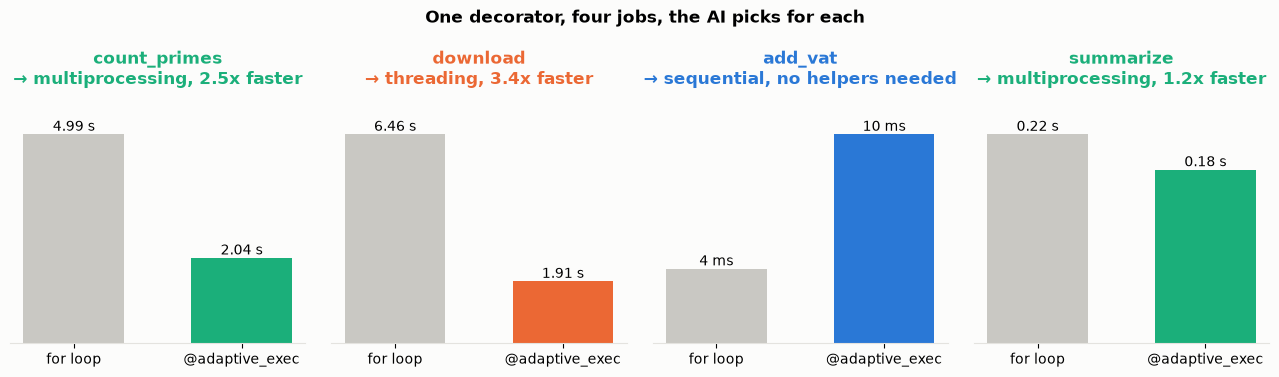

In [12]:
import matplotlib.pyplot as plt

COLORS = {"sequential": "#2a78d6", "threading": "#eb6834", "multiprocessing": "#1baf7a"}
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#e4e3df",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
                     "axes.titleweight": "bold", "font.size": 10})

fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))
for ax, r in zip(axes, [r1, r2, r3, r4]):
    color = COLORS[r["mode"]]
    ax.bar(["for loop", "@adaptive_exec"], [r["loop"], r["smart"]], 0.6, color=["#c9c8c3", color])
    for x, t in enumerate([r["loop"], r["smart"]]):
        ax.text(x, t, f"{t * 1000:.0f} ms" if t < 0.1 else f"{t:.2f} s", ha="center", va="bottom")
    result = "no helpers needed" if r["mode"] == "sequential" else f'{r["loop"] / r["smart"]:.1f}x faster'
    ax.set_title(f'{r["job"]}\n→ {r["mode"]}, {result}', color=color)
    ax.set_ylim(0, max(r["loop"], r["smart"]) * 1.2)
    ax.set_yticks([])

fig.suptitle("One decorator, four jobs, the AI picks for each", fontweight="bold")
fig.tight_layout()
fig.savefig("figures/04_demo_race.png", dpi=150)
plt.show()

- งานคิดเลข → AI เลือก **multiprocessing** (แบ่งให้หลาย core)
- งานโหลดเว็บ → AI เลือก **threading** (รอพร้อมกันหลายหน้า)
- งานจิ๋ว → AI **ไม่ใช้ตัวช่วย** เพราะเปิดตัวช่วยแพงกว่างานเอง
- งานอ่าน CSV → AI เลือก **multiprocessing** แต่งานเบา (~0.2 s) จึงเร็วขึ้นแค่นิดหน่อย
- คำตอบเหมือน for loop ทุกตัว เรียงลำดับเดิม

AI ตัดสินจาก 13 ค่าที่วัดได้ในช่วง ~50 ms แรก โมเดลเรียนจากงาน 13,603 งานบน 16 แบบเครื่อง

**ทดลองใช้:** `pip install polymorph-ai`

## 5. ข้างใน `.map()` เกิดอะไรขึ้น

ภาพเคลื่อนไหวนี้เล่นซ้ำสิ่งที่เกิดขึ้นจริงในรอบที่เพิ่งรัน (ตัวเลขทั้งหมดมาจาก `last_run`)
1. **Probe:** รันชิ้นแรกๆ จริง (~50 ms) และเก็บผลไว้
2. **Features:** วัดได้ 13 ค่า เช่น เวลาต่อชิ้น, CPU ทำงานกี่ %, ลอง 2 thread แล้วเร็วขึ้นไหม
3. **MLP:** neural network แปลง 13 ค่าเป็นความน่าจะเป็นของ 3 mode
4. **Run:** ส่ง**ฟังก์ชันเดิม**ให้ `ThreadPool.map` หรือ `Pool.map` (หลาย process) รันชิ้นที่เหลือ โค้ดของเราไม่ถูกแก้เลย

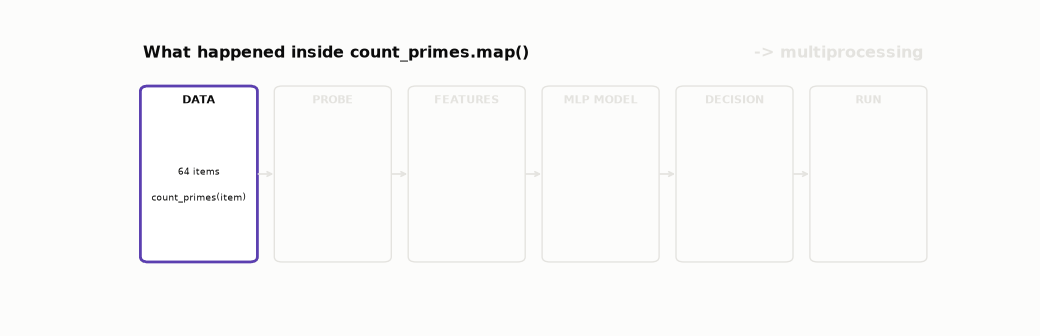

In [13]:
from live import explain       # วาด flow ด้วย matplotlib (โค้ดอยู่ใน live.py)

explain(count_primes)

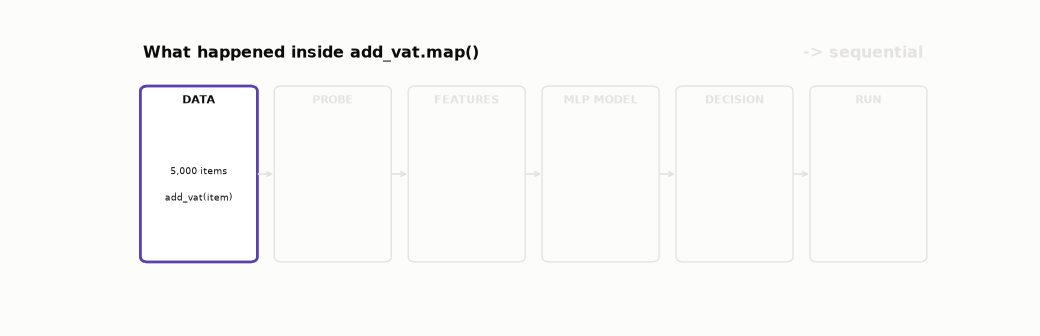

In [14]:
explain(add_vat)               # งานจิ๋ว: ไม่ต้องถาม model

In [15]:
shutdown()      # ปิดตัวช่วยทั้งหมดเมื่อเลิกใช้